In [1]:
from utils import * 
import subprocess
import json
import itertools

%load_ext autoreload 
%autoreload 2


In [2]:
msa_dir_path = '../data/genes/mmseqs/'

def get_msas_unpaired(gene_ids:list, dir_path:str='../data/genes/mmseqs/'):
    '''Load the unpaired MSAs for the specified gene IDs.
    
    :param gene_ids: The IDs of the genes to construct paired MSAs for. These should all be from the same genome.   
    :param dir_path: The path to the directory where the MSAs are stored. This function assumes the a3m files have names matching the gene ID of the query 
        sequence. 
    '''
    paths = {gene_id:os.path.join(dir_path, f'{gene_id}.a3m') for gene_id in gene_ids}
    return {gene_id:str(FASTAFile.from_file(path)) for gene_id, path in paths.items()}


# Cluster analysis: **cluster_3**

The cluster_3 proteins are conserved across all Betazoid genomes, and are annotated as P-loop ATPases

In [3]:
cluster_id = 3

In [133]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))

# Make sure to define these maps prior to filtering out the non-cluster_3 entries.
seq_to_gene_id_map = genes_df.reset_index(names='gene_id').set_index('seq').gene_id.to_dict()
gene_id_to_cluster_id_map = json.load(open('../data/genes/clusters.json'))

genes_df = genes_df[(genes_df.cluster_id == cluster_id)].copy()

# Write the protein sequences to a FASTA file and create an MSA. 
msa_path = f'../data/genes/cluster_{cluster_id}.afa'
FASTAFile.from_df(genes_df).write(f'../data/genes/cluster_{cluster_id}.faa')
if not os.path.exists(msa_path):
    subprocess.run(f'muscle -align ../data/genes/cluster_{cluster_id}.faa -output {msa_path}', shell=True, check=True)
msa = MSAFile.from_file(msa_path)

print('Number of genes:', len(genes_df))
print('Maximum length:', genes_df.seq.apply(len).max())
print('Minimum length:', genes_df.seq.apply(len).min())

print()
print(str(FASTAFile.from_df(genes_df)))

Number of genes: 11
Maximum length: 266
Minimum length: 244

>orfm.bz_0.1_191
LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLMDMILNNRMKVYSNMPLNFEQSGFNTLVQPYVSTSFFDNMPTGAIINWDEMPNDINARNFNSVKNKYVSVLSVDIAKKDDRLRGTFQFGDTVEKNLGDLCECIIIPEYVNNYSENTKEDNIQRVKEKDFLQHWIIIDKRNNDTHYELTFNLYPCIFFYNTKYKPIPLHVNHEDYIEKLKPQALSMFLSKNQNKINERFEHWNDGMKEIGKVMIR
>orfm.bz_1.1_155
MTSISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILNNKNNILSNYPIKLGKVDKINTYIPLTQTSQFDETSLHTLFIMDEMQNDLDSRDFMSPKNRYLMSWAKGLRKDDSQVIGSIQYFDFLEKRLSDLLQMIIIPTWVKQYSESEKKDIQMRLENKDFRSKWYVIDKKTNNEYIIPSINLYNFINMYDTNFKTNPLIVTHKEFLQHMKDTKSAQKYENYINDSNERIKYSLEHWLEGEKEL
>orfm.bz_2.1_22
MNKLDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNKKLIYSNMPLYYPVLEKVKINPLLETKIFDLDSGIKNCIYIMDELHNDVNAKNSMGHKNKYVTNWSVGLRKDKSKLRGSLQFFDTLEKILGLMLEVIIIPTFINKYSNDAQEDNLQRLEKKDFTVNWHIIDKKTQEIFDFPINLYPFLNMYNTKFKPMPLVINHDEYLHNLQKSSKKTYEMELEYNQRRLNDNNENWNEGMREIIINNSDFTLIKELSKQKLTI
>orfm.bz_3.1_43
MQTNRKIMNNKEIIELILSRYVVIIGGRYSRGKSLSLTALNFFDMILNGRNNVLSNMPIKSNVKGLDFNITPLIETKIFDNIPNKINIIYDEIHMDL

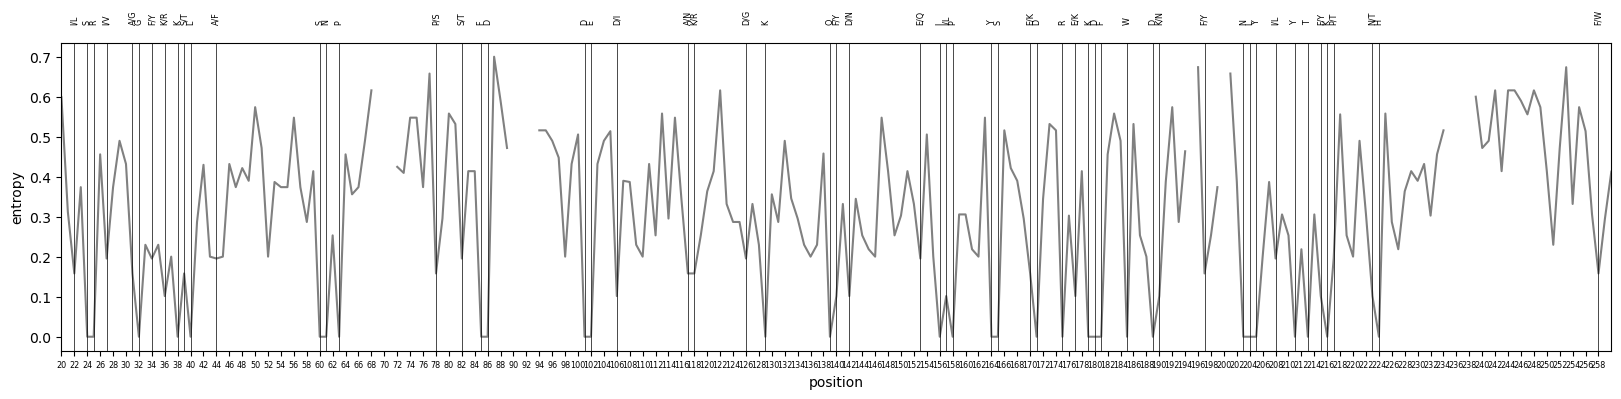

In [5]:
fig, ax = plt.subplots(figsize=(20, 4))
plot_entropy(msa, ax=ax, annotate=True, x_max=260)
plt.show()

The residues as the extreme C-terminus, starting around position 225, form an alpha-helix with very weak sequence-level similarity. It is fairly hydrophilic, and is not predicted to be a transmembrane helix, as would be expected of a pI-like membrane-associated ATPase. 

Inspection of the AlphaFold structure indicates that, despite the lack of sequence-level conservation, there does appear to be conserved negatively-charged patches, as well as conserved hydrophobic patches. 

*It seems as though there may be conserved charge patches, but for some reason none of the attempts to capture this using numerical scores seems to be working. Am instead going to look at PPI.* 

In [183]:
HYDROPHOBICITY_SCALE = {'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5}
CHARGE_SCALE = {'D': -1, 'E': -1, 'K': 1, 'R': 1, 'H': 0, 'A': 0, 'C': 0, 'F': 0, 'G': 0, 'I': 0, 'L': 0, 'M': 0, 'N': 0, 'P': 0, 'Q': 0, 'S': 0, 'T': 0, 'V': 0, 'W': 0, 'Y': 0}

def get_face(seq, patch_start:int=None, patch_stop:int=None, theta:float=100, center:float=0, width:float=120):
    '''Supply the patch coordinates so that the angles for all patches are fixed relative to the same point.'''

    if (patch_start is not None) and (patch_stop is not None):
        idxs = list(range(patch_start, patch_stop))
    else:
        idxs = list(range(len(seq)))

    df = list()
    for i in idxs:
        aa = seq[i]
        row = {'residue':aa}
        row['residue_num'] = i
        row['angle'] = (i * theta) % 360 
        row['charge'] = CHARGE_SCALE.get(aa)
        row['positive'] = row['charge'] > 0
        row['negative'] = row['charge'] < 0
        row['hydrophobicity'] = HYDROPHOBICITY_SCALE.get(aa)
        df.append(row)
    df = pd.DataFrame(df)
    df['center'] = center
    delta = ((df.angle - center + 180) % 360) - 180 # Just shifting the center to be at center rather than zero. 
    df = df[delta.abs() <= width / 2].copy()
    return df 


def get_faces(genes_df:pd.DataFrame, metric='hydrophobicity', patch_size:int=15, c_terminus_start:int=225):

    genes_df = genes_df.copy()
    genes_df['c_terminus'] = genes_df.seq.str[c_terminus_start:]
    genes_df['c_terminus_length'] = genes_df.c_terminus.apply(len)

    df = pd.DataFrame([{'gene_id':row.Index, 'c_terminus':row.c_terminus, 'patch_start':patch_start} for row in genes_df.itertuples() for patch_start in range(0, row.c_terminus_length, 2)])
    df['patch_stop'] = df.patch_start + patch_size
    df['patch'] = [row.c_terminus[row.patch_start:row.patch_stop] for row in df.itertuples()]
    df['patch_length'] = df.patch.apply(len)
    df = df[df.patch_length >= patch_size].copy()

    for row in df.itertuples():
        # Use the entire C terminus as input here; patch subset is accounted for by the patch_start and patch_stop arguments.
        faces = [get_face(row.c_terminus, patch_start=row.patch_start, patch_stop=row.patch_stop, center=center) for center in np.arange(0, 360, 5)]
        scores = [face[metric].mean() for face in faces]
        face = faces[np.argmax(scores)]

        # Fix the indexing of the residue numbers to correspond to the full-length protein. 
        face['residue_num'] = face.residue_num + c_terminus_start

        df.loc[row.Index, 'face_center'] = face['center'].values[0]
        df.loc[row.Index, 'face_residues'] = ''.join(face.residue.values)
        df.loc[row.Index, 'face_residue_nums'] = ', '.join(face.residue_num.astype(str).tolist())
        df.loc[row.Index, metric] = max(scores)

    df['patch_start'] = df.patch_start + c_terminus_start
    df['patch_stop'] = df.patch_stop + c_terminus_start
    df = df.sort_values(metric, ascending=False).drop_duplicates('gene_id')
    return df.set_index('gene_id')

faces_dfs = dict()
faces_dfs['hydrophobicity'] = get_faces(genes_df, metric='hydrophobicity')
faces_dfs['positive'] = get_faces(genes_df, metric='positive')
faces_dfs['negative'] = get_faces(genes_df, metric='negative')


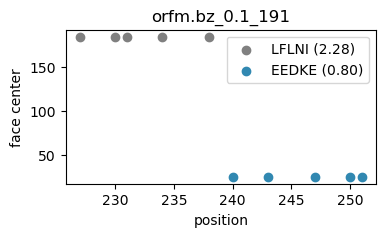

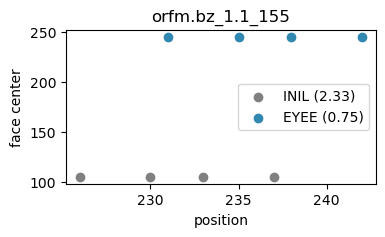

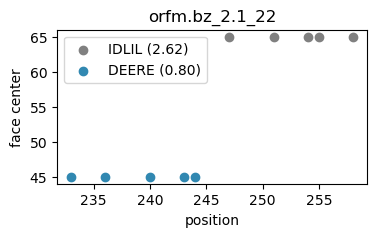

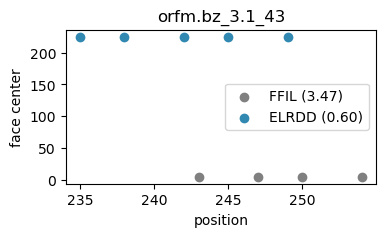

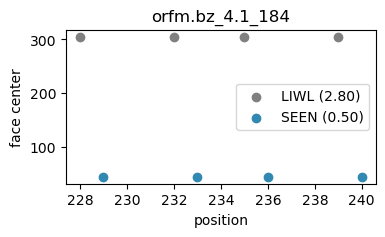

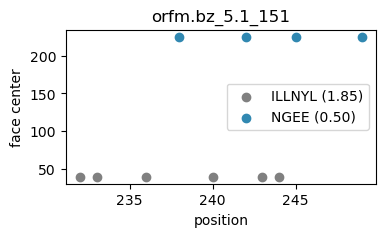

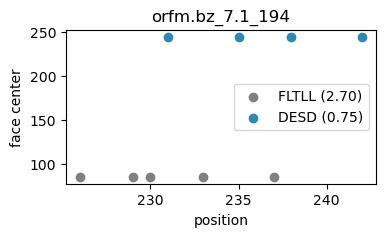

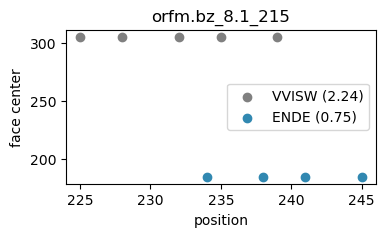

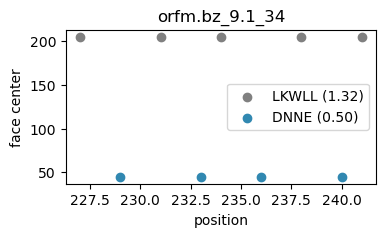

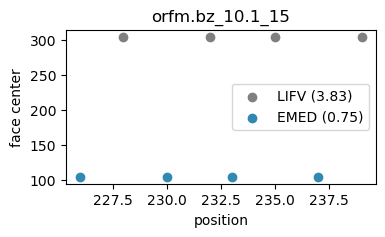

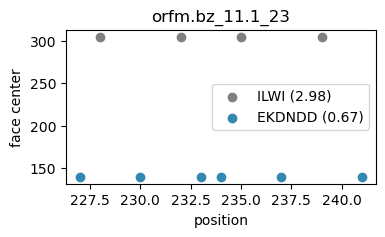

In [184]:
for gene_id in genes_df.index:

    fig, ax = plt.subplots(figsize=(4, 2))

    palette = {'hydrophobicity':'gray', 'negative':"#3188b1", 'positive':"#b14631"}

    for i, (metric, df) in enumerate(faces_dfs.items()):
        if metric == 'positive':
            continue

        center = df.loc[gene_id, 'face_center']
        residues = df.loc[gene_id, 'face_residues']
        value = df.loc[gene_id, metric]
        positions = [int(n) for n in df.loc[gene_id, 'face_residue_nums'].split(', ')]

        ax.scatter(positions, [center] * len(positions), color=palette[metric], label=f'{residues} ({value:.2f})')
        ax.set_xlabel('position')
        ax.set_ylabel('face center')

    ax.set_title(gene_id)
    ax.legend()
    plt.show()


## Protein-protein interactions

In [134]:
contacts_df = list()
for genome_id in ['bz_0']:
    contacts_path = f'0-{genome_id}_pairwise_contacts.csv'
    contacts_df += [pd.read_csv(contacts_path)]

contacts_df = pd.concat(contacts_df)
contacts_df['gene_id_0'] = contacts_df.seq_0.map(seq_to_gene_id_map)
contacts_df['gene_id_1'] = contacts_df.seq_1.map(seq_to_gene_id_map)
contacts_df['cluster_id_0'] = contacts_df.gene_id_0.map(gene_id_to_cluster_id_map)
contacts_df['cluster_id_1'] = contacts_df.gene_id_1.map(gene_id_to_cluster_id_map)
contacts_df = contacts_df[(contacts_df.cluster_id_0 == 3) | (contacts_df.cluster_id_1 == 3)].copy()

print(f'Number of potential interacting pairs:', contacts_df.drop_duplicates(['cluster_id_1', 'cluster_id_0']).name.nunique())


Number of potential interacting pairs: 9


In [135]:
contacts_df

,idx_0,chain_id_0,residue_num_0,residue_0,seq_0,idx_1,chain_id_1,residue_num_1,residue_1,seq_1,pae,contact_prob,name,model,gene_id_0,gene_id_1,cluster_id_0,cluster_id_1
142,65,A,65,L,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,290,B,194,N,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,7.0,0.54,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3
143,65,A,65,L,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,293,B,197,P,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,7.0,0.67,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3
144,66,A,66,F,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,289,B,193,F,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,5.9,0.62,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3
145,66,A,66,F,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,290,B,194,N,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,4.9,0.74,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3
146,66,A,66,F,MKETIIIQNAGDFPVEIRKCIKVDTQIFRLEGKDEAIKHSGKPCIN...,293,B,197,P,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,5.5,0.61,orfm.bz_0.1_36-orfm.bz_0.1_191,seed-2_sample-0,orfm.bz_0.1_36,orfm.bz_0.1_191,1434,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3799,15,A,15,I,MNRYNIYRNTYLIGFIVADRYLLDTKDVAQFF,77,B,45,M,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,8.2,0.52,orfm.bz_0.1_31-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_31,orfm.bz_0.1_191,1439,3
3800,15,A,15,I,MNRYNIYRNTYLIGFIVADRYLLDTKDVAQFF,80,B,48,I,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,7.9,0.57,orfm.bz_0.1_31-orfm.bz_0.1_191,seed-3_sample-0,orfm.bz_0.1_31,orfm.bz_0.1_191,1439,3
3801,12,A,12,I,MNRYNIYRNTYLIGFIVADRYLLDTKDVAQFF,229,B,197,P,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,11.3,0.55,orfm.bz_0.1_31-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_31,orfm.bz_0.1_191,1439,3
3802,15,A,15,I,MNRYNIYRNTYLIGFIVADRYLLDTKDVAQFF,80,B,48,I,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,10.5,0.64,orfm.bz_0.1_31-orfm.bz_0.1_191,seed-1_sample-0,orfm.bz_0.1_31,orfm.bz_0.1_191,1439,3


In [9]:
def get_h_mu(seq, delta:float=100):
    '''Based on the equation from Eisenberg et. al. 1982.
    From https://pmc.ncbi.nlm.nih.gov/articles/PMC3189734/, a typical average hydrophobicity for a TMH is > 0.4 on the non-normalized scale. 
    
    From https://pmc.ncbi.nlm.nih.gov/articles/PMC3189734/ (the Fauchere and Pliska scale), most things > 0.75 are transmembrane. 
    
    :param delta: The angular rotation between residues, which is 100 degrees for an alpha helix.
    '''
    scale = {'A':0.25, 'R':-1.76, 'N':-0.64, 'D':-0.72, 'C':0.04, 'Q':-0.69, 'E':-0.62, 'G':0.16, 'H':-0.40, 'I':0.73, 'L':0.53, 'K':-1.10, 'M':0.26, 'F':0.61, 'P':-0.07, 'S':-0.26, 'T':-0.18, 'W':0.37, 'Y':0.02, 'V':0.54}
    scale = {'A':0.31,'R':-1.01,'N':-0.60,'D':-0.77,'C':1.54,'Q':-0.22,'E':-0.64,'G':0.00,'H':0.13,'I':1.80,'L':1.70,'K':-0.99,'M':1.23,'F':1.79,'P':0.72,'S':-0.04,'T':0.26,'W':2.25,'Y':0.96,'V':1.22}

    N = len(seq)
    h = sum(scale[aa] for aa in seq) / N # Get the average hydrophobicity.

    # This is the magnitude of the sum of the hydrophobicity vectors for the helix. 
    mu = sum(scale[aa] * np.sin(delta * i) for i, aa in enumerate(seq)) ** 2 
    mu += sum(scale[aa] * np.cos(delta * i) for i, aa in enumerate(seq)) ** 2 
    mu = np.sqrt(mu)
    return h, mu / N

# for row in genes_df.itertuples():
#     seq = row.seq[225:]
#     h, mu = get_h_mu(seq)
#     print(row.Index, seq, str(h), str(mu))



## Oligomerization 

The Foldseek and InterProScan hits cluster_3 proteins are P-loop ATPases. It is therefore likely that cluster_3 proteins oligomerize in some way, but the most favorable conformation could provide insight into its function. If a cluster_3 homo-multimer prefers to fold as a ring-shaped pentamer, for example, this could suggest some similarity to a viral packaging ATPases or clamp loaders [[Simpson et. al. 2000](https://www.nature.com/articles/35047129), [Erzberger et. al. 2006](https://www.nature.com/articles/nsmb1115)]. If no homo-oligomeric assemblies form stable ring structures, this could suggest RecA-like activity.

Based on preliminary exploratory folding on the AlphaFold web server, co-folding cluster_3 ATPases with ATP and magnesium ions yields the highest-confidence structure predictions; ipTM scores are extremely low when folding higher-order multimers without ligands. This suggests that either (1) ligand-binding promotes cluster_3 oligomerization or (2) AlphaFold is more familiar with ATP-bound versions of ATPase oligomers. Either way, we opted to **co-fold all potential oligomers with magnesium and ATP.**

We chose to try **all possible oligomeric configurations between 1 and 8 subunits.** Though some ATPases form 12-mers (usually as a double hexamer, e.g. ClpB), these are far rarer than hexameric structures.


In [ ]:
alphafold_input_dir = f'../data/genes/alphafold/af_input/cluster_3'
alphafold_output_dir = f'../data/genes/alphafold/af_output/cluster_3' 
os.makedirs(alphafold_input_dir, exist_ok=True)

# Configure the AlphaFold3 job, using fewer diffusion samples and recycles to reduce runtime. 
alphafold_params = dict()
alphafold_params['--num_diffusion_samples'] = 1 # Number of diffusion samples to generate, 5 by default. 
alphafold_params['--num_recycles'] = 5 # Number of recycles to use during inference (refinement steps). 10 by default, dropped here to mitigate runtime. 

In [ ]:
msas = get_msas_unpaired(genes_df.index)

print('Number of genes with custom MSAs:', len(msas))
assert len(msas) == len(genes_df), f'All of the conserved gene clusters should have a custom MSA in {msa_dir_path}'

Number of genes with custom MSAs: 11


In [ ]:
for row in genes_df.itertuples():

    for num_subunits in range(2, 9):
        # Fold with more seeds to get reasonable error bars for downstream analysis of the central pore.
        input = AlphaFoldInputFile(f'{row.Index}_{num_subunits}mer-mg_atp', version=2, num_seeds=10)  
        input.add_seq(row.seq, n=num_subunits, paired_msa='', unpaired_msa=msas[row.Index])
        input.add_mg(n=num_subunits)
        input.add_atp(n=num_subunits)
        input.write(os.path.join(alphafold_input_dir, f'{input.name}.json'))


cmd = [f'run_alphafold3 --input_dir=/root/af_input/{os.path.basename(alphafold_input_dir)}/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output']
cmd += [f'{param} {value}' for param, value in alphafold_params.items()]
cmd = ' '.join(cmd)
cmd = f'sbatch --partition gpu --gpus 1 --wrap "{cmd}"'
print(cmd)

sbatch --partition gpu --gpus 1 --wrap "run_alphafold3 --input_dir=/root/af_input/cluster_3/ --model_dir=/root/models --db_dir=/root/public_databases --output_dir=/root/af_output --num_diffusion_samples 1 --num_recycles 5"


## Foldseek search 

Structures generated using the custom MSAs were used to query PDB, UniProt, SwissProt, and BFVD. 

1. **RecA:** This is a helicase which is involved in DNA damage repair. It catalyzes an ATP-dependent DNA strand-exchange reaction that is the central step in the repair of dsDNA breaks by homologous recombination. Typically, RecA proteins are around 350 amino acids in length, and interact with both ssDNA and dsDNA through distinct binding sites [[Bell 2005](https://onlinelibrary.wiley.com/doi/10.1111/j.1365-2958.2005.04876.x)]. Notably, only the N-terminal ~250 residues align to the cluster_3 proteins. 

2. **gp4:** This is a homo-hexameric dual-function helicase-primase which is encoded by the T7 bacteriophage (a dsDNA virus). The helicase and primase activities of gp4 reside in the C-terminal and N-terminal halves of the protein, respectively; all Foldseek hits are to the N-terminus, so it is unlikely that cluster_3 has a similar dual function [[He et. al. 2005](https://www.jbc.org/article/S0021-9258(20)66832-6/fulltext)]. It is also involved in branch migration. 

3. **HerA:** The HerA ATPase cooperates with the NurA nuclease and the Mre11-Rad50 complex for the repair of double-strand DNA breaks in thermophilic archaea. The HerA ring forms a toroid with an approximately 25 Å wide central channel that is broad enough to accommodate B-form dsDNA. [[Rzechorzek et. al. 2015](www.jbc.org/article/S0021-9258(20)66832-6/fulltext)]

4. **DnaA:** This protein seems to oligomerize into helical filaments, much like RecA. It is a replication initiator, which helps remodel DNA superstructure at replication origins to enable replisome assembly [[Erzeberger et. al. 2005](https://www.nature.com/articles/nsmb1115)]. 

5. **DnaB:** This is a ring-shaped, hexameric helicase that unwinds the DNA replication fork while encircling one DNA strand. DnaB can also encircle both DNA strands and then actively translocate along the duplex. With two strands positioned inside its central channel, DnaB translocates with sufficient force to displace proteins tightly bound to DNA with no resultant DNA unwinding. While encircling two DNA strands, it can drive branch migration of a Holliday junction, so may be involved in DNA recombination. [[Kaplan et. al. 2002](https://www.cell.com/molecular-cell/fulltext/S1097-2765(02)00642-1?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS1097276502006421%3Fshowall%3Dtrue)]

6. **Zona occludens toxin:**  Zot is the second major toxin encoded by a filamentous phage CTX-phi, and is a motor protein that mediates the trans-envelope assembly and secretion of filamentous phages (protein pI) [[Ma et. al. 2022](https://www.biorxiv.org/content/10.1101/2022.09.21.508815v1), [Iribarren et. al. 2024](https://www.mdpi.com/2076-2607/12/3/504), [Perez-Raytor et. al. 2020](https://pmc.ncbi.nlm.nih.gov/articles/PMC7541967/)]. In a paper screening gene databases for Inoviruses, "The criteria used to determine genuine inovirus pI-like PCs were: the PC members closest known functional domain was Zot... no significant similarity could be identified to any other type of ATPase" [[Roux et. al. 2019](https://www.nature.com/articles/s41564-019-0510-x)]


In [ ]:
foldseek_search_df = pd.concat([pd.read_csv(path, sep='\t', names=FOLDSEEK_FIELDS).assign(path=path) for path in glob.glob('../data/genes/foldseek/level_1_conserved_clusters*')])
foldseek_search_df = foldseek_search_df[foldseek_search_df.query_id.isin(genes_df.index)].copy()

filters = dict()
filters['low_tm_score'] = foldseek_search_df.alignment_tm_score < 0.7
filters['low_query_coverage'] = foldseek_search_df.query_coverage < 0.5
filters['short_alignment'] = foldseek_search_df.alignment_length < 100 # Slightly larger minimum alignment length considering the length of the protein. 
filters['synthetic'] = foldseek_search_df.target_header.str.contains('Computationally designed|synthetic|de novo|De novo|Engineered')

foldseek_search_df = apply_filters(filters, foldseek_search_df)


apply_filters: 32315 entries removed by low_tm_score.
apply_filters: 208 entries removed by low_query_coverage.
apply_filters: 43 entries removed by short_alignment.
apply_filters: 9 entries removed by synthetic.


In [ ]:
categories = dict()
categories['genome packaging NTPase'] = foldseek_search_df.target_header.str.contains('genome packaging NTPase')
categories['RecA'] = foldseek_search_df.target_header.str.contains('RecA|RECA|recA')
categories['gp4'] = foldseek_search_df.target_header.str.contains('gp4')
categories['HerA'] = foldseek_search_df.target_header.str.contains('HerA|DUF87') 
categories['DnaB'] = foldseek_search_df.target_header.str.contains('DnaB')
categories['DnaA'] = foldseek_search_df.target_header.str.contains('DnaA') # Replication initiator, binds to origin and melts duplex DNA. 
categories['zona occludens toxin'] = foldseek_search_df.target_header.str.contains('Zot|Zonula|Zona|Toxin-like protein', case=False)
categories['helicase'] = foldseek_search_df.target_header.str.contains('DNA helicase', case=False)
categories['uncharacterized'] = foldseek_search_df.target_header.str.contains('uncharacterized', case=False)
categories['AAA family ATPase'] = foldseek_search_df.target_header.str.contains('AAA family ATPase|AAA-domain-containing|ATP-binding|AAA')
categories['ATPase'] = foldseek_search_df.target_header.str.contains('ATPase') & ~categories['AAA family ATPase']
categories['transposase'] = foldseek_search_df.target_header.str.contains('transposase', case=False)
categories['filamentous phage protein'] = foldseek_search_df.target_header.str.contains('Cf1c|Spiroplasmavirus|Plectrovirus|assembly', case=False)

categories = list(zip(*list(categories.items())))
foldseek_search_df['category'] = np.select(condlist=categories[-1], choicelist=categories[0], default='none')

# foldseek_search_df[foldseek_search_df.query_end < 200].sort_values('alignment_tm_score').drop_duplicates('target_id').iloc[-100:][['query_length', 'target_length', 'query_start', 'query_end', 'target_end', 'target_header']]

The Foldseek results indicate ovewhelming structural homology with the zona occludens toxin (Zot) and related proteins, which are ring-shaped ATPase involved in the assembly of filamentous phages. Other strong hits are to ring-shaped ATPases which also translocate dsDNA through their central pore (e.g. HerA and DnaB). It seems likely that the cluster_3 ATPase has similar activity, though it is unclear if the dsDNA translocation activity is involved in (1) DNA recombination, (2) filamentous phage-like assembly and extrusion, or (3) DNA replication. 

Notably, cluster_3 proteins do not appear to have a transmembrane domain, as is characteristic of the pI phage assembly proteins. 

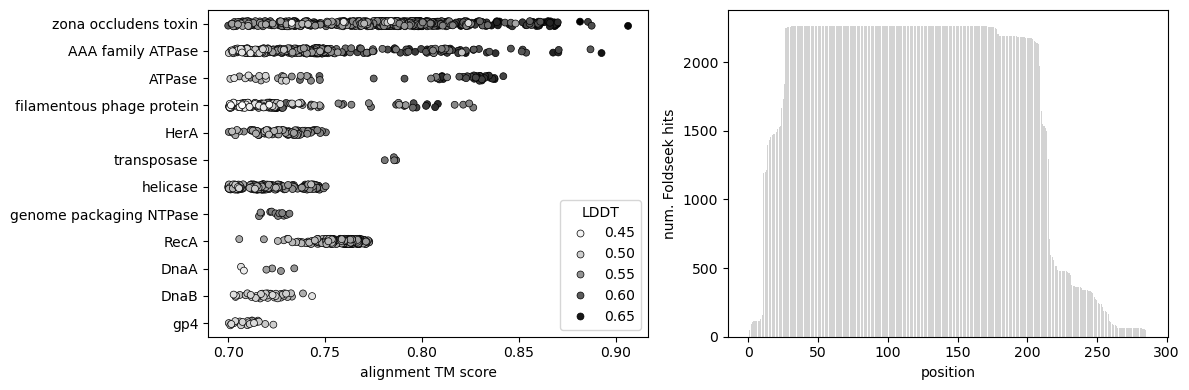

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

ax = axes[0]
figure_df = foldseek_search_df[~foldseek_search_df.category.isin(['none', 'uncharacterized'])].copy()
figure_df = figure_df.sort_values('lddt', ascending=False).drop_duplicates('target_id') # Keep the best hit to each target. 
sns.stripplot(figure_df, y='category', x='alignment_tm_score', ax=ax, hue='lddt', palette='Grays', edgecolor='black', linewidth=0.5)
ax.set_xlabel('alignment TM score')
ax.get_legend().set_title('LDDT')
ax.set_ylabel('')

ax = axes[1]
# Get the Foldseek hit start and stop indices relative to the MSAFile. 
figure_df['msa_start'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_start, row.query_id), axis=1) 
figure_df['msa_stop'] = figure_df.apply(lambda row : msa.map_idx_to_msa(row.query_end, row.query_id), axis=1) 

positions = np.arange(msa.n_cols)
heights = np.zeros(len(positions))
for row in figure_df.itertuples():
    heights[np.arange(row.msa_start, row.msa_stop)] += 1 

ax.bar(positions, heights, color='lightgray', lw=0, edgecolor='black')
ax.set_ylabel('num. Foldseek hits')
ax.set_xlabel('position')

fig.tight_layout()
plt.show()

In [ ]:
msa.show()

0	..........MN..K.LDLLHSLFSRHIILWGGEYGRSKSLSLCAFTFLECLLDNKKLIYSNMPLYYPVL..EKVKINPLLETKIFDLDS..GIKNCIYIMDELHNDVNAKNSMGHKNKYVTNWSVGLRKDKSKLRGSLQFFDTLEKILGLMLEVIIIPTFINKYSNDAQEDNLQRLEKKDFTVNWHIIDKKTQE.IFDF.PINLYPFLNMYNTKFKPMPLVINHDEYLHNLQKSS.KKTYEMELEYNQRRLNDNNENWNEGMREI.IINNSDFTLIKELSKQKLTI	287	orfm.bz_2.1_22
0	..........MN..N.LDKLNIIFSRWIIIFGGEFGRCKSLSITALTFLELLYTKKSKIISNMPLYYPM...FNTEILPLIQSLQFDINKLSDIENSIIILDELQSILNSRDFASEKNKFVTAFSVGFRKDKIKFRGSLQFFDTLEKVMGLMLEMIIIPSFVNTYSDDSDKDREIRLEKKDFLVKWKCIDKKADI.IFEI.VINLYPFLNMYNTNFKPYQLVINHESYLEKLKKNK.KNYYNEYVETVDRQINESNVNWYDGLQEI.I................DNY	287	orfm.bz_8.1_215
0	..........MT..SISEIFDIIFSRKIIIFGGEFGRGKTLCMTAYAYFASILNNKNNILSNYPIKLGKV.DKINTYIPLTQTSQFDETS....LHTLFIMDEMQNDLDSRDFMSPKNRYLMSWAKGLRKDDSQVIGSIQYFDFLEKRLSDLLQMIIIPTWVKQYSESEKKDIQMRLENKDFRSKWYVIDKKTNN.EYIIPSINLYNFINMYDTNFKTNPLIVTHKEFLQHMKDTKSAQKYENYINDSNERIKYSLEHWLEGEKEL.....................	287	orfm.bz_1.1_155
0	LFVW.....NMN..T.KEILDIISSRKVILIAGEYGRGKSLSGTALIFMLCVLSGSYNILSNIPLYFGK

In [ ]:
foldseek_search_df[(foldseek_search_df.query_length - foldseek_search_df.query_end) < 20][['target_header', 'target_length']]
foldseek_search_df[foldseek_search_df.category == 'RecA'][['target_start', 'target_end', 'target_length']]

,target_start,target_end,target_length
2934,12,234,300
2946,26,247,308
2947,25,241,301
2954,29,249,310
2959,28,250,311
...,...,...,...
38313,58,284,379
38317,98,323,430
38318,126,349,452
38528,46,634,711


## HOLE

HOLE is a program that allows the analysis and visualisation of the pore dimensions of the holes through molecular structures of ion channels [[Smart et al. 1996](https://pubmed.ncbi.nlm.nih.gov/9195488/)]. Here, we apply HOLE to the hexameric assembly of cluster_3 proteins in order to characterize the dimensions and lining residues of the central pore, with the goal of predicting a likely substrate.

Electron microscopy studies show that these hexameric replication fork helicases are ring-shaped with a central channel of ∼25–40 angstroms in diameter [[Kaplan et. al. 2002](https://www.cell.com/molecular-cell/fulltext/S1097-2765(02)00642-1?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS1097276502006421%3Fshowall%3Dtrue)]. 

In [ ]:
hole_input_dir = '../data/genes/hole/input'
hole_output_dir = '../data/genes/hole/output'    
HOLE_MODEL_PATHS = dict()

In [ ]:


# Copy the CIF files to the HOLE_INPUT_DIR as PDB files, as HOLE only accepts PDB files.
for name in names:

    # Based on ipTM results above, focus on the Mg-ATP bound hexamers only. 
    if (get_ligand(name) != 'mg_atp') or (get_num_subunits(name) != 6):
        continue 

    if not os.path.exists(os.path.join(ALPHAFOLD_OUTPUT_DIR, name)):
        print(f'Skipping {name}, as the AlphaFold output directory no longer exists.')
        continue

    output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
    models = sorted(list(output.model_paths))
    for i, model in enumerate(models): # Need to replace the model name with an integer because of issues with input file line length limits.
        output_path = os.path.join(HOLE_INPUT_DIR, f'{name}.{i}.pdb')
        cif_to_pdb(output.model_paths[model], output_path)
        # HOLE_MODEL_PATHS[output_path] = output.model_paths[model] # Store the path to the original model


In [ ]:
HOLE_INPUT_DIR = '../data/genes/hole/input/cluster_3/'
HOLE_OUTPUT_DIR = '../data/genes/hole/output/cluster_3/'    
os.makedirs(HOLE_INPUT_DIR, exist_ok=True)
os.makedirs(HOLE_OUTPUT_DIR, exist_ok=True)

# Based on looking at the structure, in order to preserve the orientation of the pore as used for the cluster_3 multimers, should use the cluster_1 chains
# and the following residue numbers. 
start_residue_num, end_residue_num = 1, 220


paths = list()
# Copy the CIF files to the HOLE_INPUT_DIR as PDB files, as HOLE only accepts PDB files.
for name in names:
    
    if not os.path.exists(os.path.join(ALPHAFOLD_OUTPUT_DIR, name)):
        print(f'Skipping {name}, as the AlphaFold output directory no longer exists.')
        continue

    output = AlphaFoldOutput(os.path.join(ALPHAFOLD_OUTPUT_DIR, name))
    models = sorted(list(output.model_paths))
    
    for i, model in enumerate(models): # Need to replace the model name with an integer because of issues with input file line length limits.
        output_path = os.path.join(HOLE_INPUT_DIR, f'{name}.{i}.pdb')
        paths.append(cif_to_pdb(output.model_paths[model], output_path)) # Convert the CIF AlphaFold output to PDB and rename. 

paths = hole_main(paths, output_dir=HOLE_OUTPUT_DIR, chain_ids=None, start_residue_num=start_residue_num, end_residue_num=end_residue_num)

if not os.path.exists('analysis-1-cluster_3-hole.csv'):

    hole_df = list()
    for path in tqdm(paths, desc='Processing HOLE output.'):
        name = os.path.basename(path).replace('.pdb', '')
        hole_df.append(hole_process_output(name, input_dir=HOLE_INPUT_DIR, output_dir=HOLE_OUTPUT_DIR))

    hole_df = pd.concat(hole_df)
    hole_df.to_csv('analysis-1-cluster_3-hole.csv')

hole_df = pd.read_csv('analysis-1-cluster_3-hole.csv', index_col=0)
hole_df['genome_id'] = hole_df.name.apply(get_genome_id)
hole_df = hole_df[hole_df.name.str.contains('mg_atp')].copy()


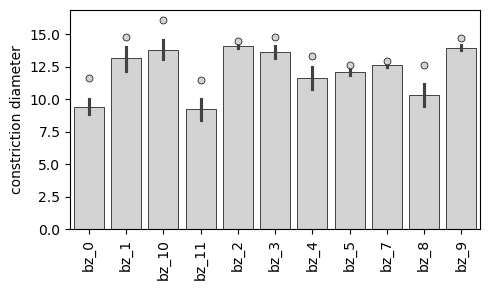

In [ ]:
# First, want to look at the approximate pore diameters (which include the Van Der Waals radius). Based on these results, it seems as though the predictions
# for ATP-bound structures are far more consistent, and generally tend to have larger radii. For subsequent analysis, I will focus on the ATP-bound 6mers. 

fig, ax = plt.subplots(figsize=(5, 3))

# Want num_subunits, ligands, and the constriction point. It would also be useful to get PAE at the constriction point (although
# the actual pore-lining residues will be needed for this)
figure_df = list() 

for path in glob.glob(os.path.join(HOLE_OUTPUT_DIR, '*pdb')):

    name, model = os.path.basename(path).replace('.pdb', '').split('.')
    if not ((get_ligand(name) == 'mg_atp') and (get_num_subunits(name) == 6)):
        continue 

    pdb_df = StructureFile.from_file(path).to_df(atoms=['QSS'], residues=['SPH'])

    data = {'name':name, 'model':model, 'genome_id':get_genome_id(name)}
    data['ligand'] = 'ATP' if (('mg_atp') in name) else 'ADP'
    data['num_subunits'] = get_num_subunits(name)
    data['min_radius'] = pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    data['min_diameter'] = 2 * pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    figure_df.append(data)
figure_df = pd.DataFrame(figure_df)


figure_df = figure_df.sort_values(['genome_id', 'min_radius'], ascending=[True, False])
sns.barplot(figure_df, ax=ax, x='genome_id', y='min_diameter', color='lightgray', edgecolor='black', lw=0.5)
# sns.stripplot(figure_df, ax=ax, x='genome_id', y='min_diameter',  color='lightgray', edgecolor='black', linewidth=0.5)
sns.stripplot(figure_df.drop_duplicates('genome_id', keep='first'), ax=ax, x='genome_id', y='min_diameter',  color='lightgray', edgecolor='black', linewidth=0.5)
ax.set_xlabel('')
ax.set_ylabel('constriction diameter')
ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)

fig.tight_layout()
plt.show()

In [ ]:
# https://pmc.ncbi.nlm.nih.gov/articles/PMC9228878/ They measure cavity diameter using microscopy, not the pore constriction based on crystal structure.

In [ ]:
for path in glob.glob(os.path.join(HOLE_OUTPUT_DIR, '*pdb')):

    name, model = os.path.basename(path).replace('.pdb', '').split('.')
    if not ((get_ligand(name) == 'mg_atp') and (get_num_subunits(name) == 6)):
        continue 

    pdb_df = StructureFile.from_file(path).to_df(atoms=['QSS'], residues=['SPH'])

    data = {'name':name, 'model':model, 'genome_id':get_genome_id(name)}
    data['ligand'] = 'ATP' if (('mg_atp') in name) else 'ADP'
    data['num_subunits'] = get_num_subunits(name)
    data['min_radius'] = pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    data['min_diameter'] = 2 * pdb_df.b_factor.min() # The radius is stored in the b_factor field. 
    figure_df.append(data)
figure_df = pd.DataFrame(figure_df)

figure_df

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:
residues = ['LYS', 'ARG', 'ASN',  'GLN', 'PHE', 'TYR']
colors = ['#8A5E3B', '#B38A5A', '#9AA45A', '#4F9D78', '#5A93A0', '#7A7FB8']
palette = dict(zip(residues, colors))

def plot_pore(hole_df:pd.DataFrame, palette=palette, path:str=None, title:str=None):

    figure_df = hole_df.copy()
    figure_df['diameter'] = figure_df.distance * 2 # This will not include the Van Der Waals radius. 
    figure_df['ligand'] = figure_df['name'].apply(lambda name : 'ATP' if (('mg_atp') in name) else 'ADP')

    # Want to obtain the closest residue from each chain for each sphere center, so there should be num_subunits entries per sph_idx.

    fig, ax = plt.subplots(figsize=(10, 3))

    # I checked, and none of the spheres share the same residue across all models, which could be due to small variations in the 
    # models, or because there are different numbers of spheres... or who knows. 

    df = list()
    for idx, df_ in figure_df.groupby('sph_idx'):
        row = {'sph_idx':idx}
        row['consensus_residue'] = df_.residue.value_counts().index[0]
        row['consensus_residue_confidence'] = (df_.residue == row['consensus_residue']).mean()
        df.append(row)
    figure_df = figure_df.merge(pd.DataFrame(df), how='left', on='sph_idx')

    sns.lineplot(figure_df, x='sph_idx', y='diameter', color='black')
    y_min, y_max = ax.get_ylim()

    for residue, color in palette.items():
        idxs = figure_df[figure_df.consensus_residue == residue].sph_idx.unique()
        ax.vlines(idxs, ymin=y_min, ymax=y_max, color=color, zorder=-1, alpha=0.5, label=residue, lw=1)

    diameters = figure_df.groupby('sph_idx').diameter.mean()
    min_diameter_idx = np.argmin(diameters)
    min_diameter = min(diameters) 
    print(f'plot_pore: Minimum diameter of {min_diameter} at SPH {min_diameter_idx}.')
    ax.legend(loc='lower right')

    ax.set_xlim(xmin=0, xmax=figure_df.sph_idx.max())
    ax.set_xlabel('SPH index')
    ax.set_ylabel('diameter (angstroms)')

    if title is not None:
        ax.set_title(title)

    if path is not None:
        fig.savefig(path, dpi=500, format='png')
    plt.show()

for genome_id, df in hole_df.groupby('genome_id'):
    plot_pore(df, path=os.path.join(FIGURE_DIR, f'pore_{genome_id}_atp.png'), title=genome_id)
    break

# I took a look at the PAEs, which were around 10-15 A around the constriction points. However, because model predictions are consistently 
# predicting fairly small pores, I think it is likely that the substrate is ssDNA.

KeyError: 'genome_id'

In [ ]:
# Note that the residue nums in the hole_df are one-indexed, as they are loaded directly from the PDB file.
 
hole_df['gene_id'] = hole_df.genome_id.map(GENOME_ID_TO_GENE_ID_MAP)
hole_df['msa_residue_num'] = hole_df.apply(lambda row : msa.map_idx_to_msa(row.residue_num - 1, row.gene_id), axis=1)

In [ ]:
hole_df.msa_residue_num.value_counts()
# Want to look at how frequently certain residue appear as lining the pore. 

df = hole_df.drop_duplicates(['gene_id', 'residue_num']) # Treat all chains as effectively the same. 
df['residue_num'] = df.residue_num - 1
df['msa_residue_num'] = df.apply(lambda row : msa.map_idx_to_msa(row.residue_num, row.gene_id), axis=1)
df['num_genomes'] = df.groupby('msa_residue_num').genome_id.transform('nunique')

df[df.num_genomes >= 11] #.residue.value_counts()
pore_residue_nums = df[df.num_genomes >= 3].msa_residue_num.unique()

plot_pore: Minimum diameter of 15.945386010941707 at SPH 397.


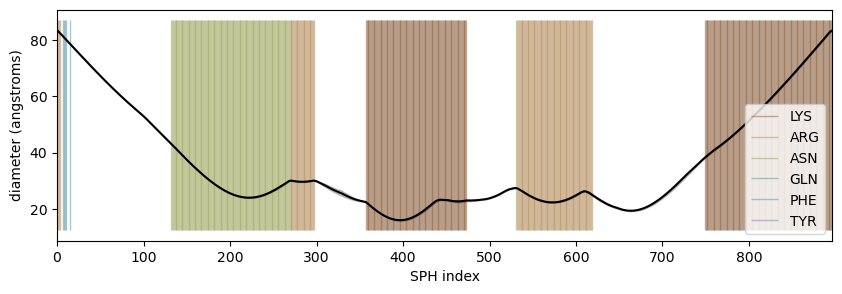

In [ ]:
# https://pmc.ncbi.nlm.nih.gov/articles/PMC4376295 is the crystal structure of the HerA hexameric assembly from the thermophilic archaeon 
# Sulfolobus solfataricus, in complex with a non-hydrolysable analogue of ATP.

# I want to see just how accurately this approach estimates the pore size.
#   (1) I selected a HerA ATPase from UniProt (Q97WG8). These are likely in the same family of DNA translocation motors to which my ATPase
#       belongs, and have a pore size sufficient to accomodate B-form dsDNA (23 A).
#   (2) I folded a HerA ATPase using the AlphaFold server, and now want to 

gene_id = 'q97wg8'
gene_id = 'f2z5z6'
HOLE_INPUT_DIR = f'../data/genes/hole/input/{gene_id}_6mer_mg_atp/'
HOLE_OUTPUT_DIR = f'../data/genes/hole/output/{gene_id}_6mer_mg_atp/'   
os.makedirs(HOLE_INPUT_DIR, exist_ok=True)
os.makedirs(HOLE_OUTPUT_DIR, exist_ok=True) 

output = AlphaFoldServerOutput(f'../data/genes/alphafold/server/{gene_id}_6mer_mg_atp')
# find . -type f -name 'fold_*' -exec rename 's|/fold_|/|' {} +

for i, model in enumerate(sorted(list(output.model_paths.keys()))):
    output_path = os.path.join(HOLE_INPUT_DIR, f'{output.name}.{i}.pdb')
    cif_to_pdb(output.model_paths[model], output_path) # Convert the CIF AlphaFold output to PDB and rename. 

input_paths = glob.glob(os.path.join(HOLE_INPUT_DIR, '*pdb'))
paths = hole_main(input_paths, output_dir=HOLE_OUTPUT_DIR, chain_ids=None, start_residue_num=65, end_residue_num=267)

if not os.path.exists(f'analysis-1-cluster_3-{gene_id}_hole.csv'):

    hole_df = list()
    for path in tqdm(paths, desc='Processing HOLE output.'):
        name = os.path.basename(path).replace('.pdb', '')
        hole_df.append(hole_process_output(name, input_dir=HOLE_INPUT_DIR, output_dir=HOLE_OUTPUT_DIR))

    hole_df = pd.concat(hole_df)
    hole_df.to_csv(f'analysis-1-cluster_3-{gene_id}_hole.csv')

hole_df = pd.read_csv(f'analysis-1-cluster_3-{gene_id}_hole.csv', index_col=0)
plot_pore(hole_df)

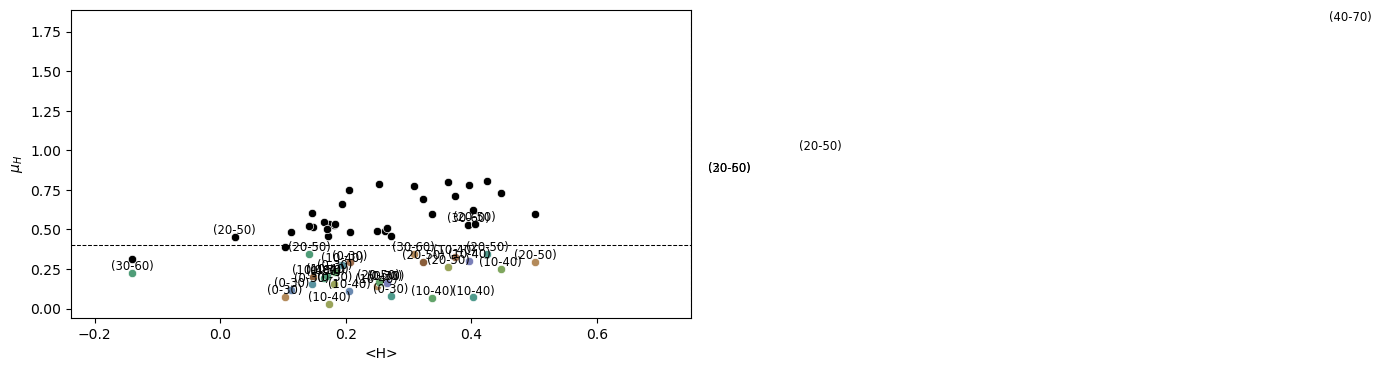

In [ ]:


# def get_max_mu(seq:str, n:int=200):
#     ''''''
#     def get_random_seqs(seq:str, n:int=n):
#         seq = list(seq)
#         seqs = list()
#         for _ in range(n):
#             np.random.shuffle(seq)
#             seqs.append(''.join(seq))
#         return seqs

#     return max([get_h_mu(s) for s in get_random_seqs(seq)], key=lambda x : x[-1])


# def plot_eisenberg(seq, start:int=None, stop:int=None, ax=None, color='gray', plot_max_mu:bool=True, annotate:bool=False, **kwargs):
#     ''''''
#     seq = seq[start:stop] if ((start is not None) and (stop is not None)) else seq
#     h, mu = get_h_mu(seq)

#     if annotate:
#         ax.text(h, mu, f'({start}-{stop})', ha='center', va='bottom', fontsize='small')

#     sns.scatterplot(x=[h], y=[mu], color=color, **kwargs)

#     if plot_max_mu:
#         h, mu = get_max_mu(seq)
#         sns.scatterplot(x=[h], y=[mu], color='black', **kwargs)




# def plot(seq, window_size:int=10, step_size:int=10, color:str='gray', ax=None):

#     starts = np.arange(0, len(seq), step_size)
#     stops = [start + window_size for start in starts]
#     for start, stop in zip(starts, stops):
#         plot_eisenberg(seq, start=start, stop=stop, ax=ax, color=color, annotate=True)



# fig, ax = plt.subplots(figsize=(8, 4))
# for row in genes_df.itertuples():
#     plot(row.seq[225:], window_size=30, color=GENOME_ID_COLORS[get_genome_id(row.Index)], ax=ax)

# ax.axhline(0.4, ls='--', color='black', lw=0.75)
# ax.axvline(0.75, ls='--', color='black', lw=0.75)
# ax.set_xlabel('<H>')
# ax.set_ylabel(r'$\mu_H$')
# ax.set_xlim(xmax=0.75)

# plt.show()